1) Model Selection

Population Dynamics 

2) Paramater Research 

Source: Jounral of Mammology 

DOI: 10.1093/jmammal/gyv083

Title: Reproduction, abundance, and population growth for a fisher (Pekania pennanti) population in the Sierra National Forest, California

Information: 

    growth rate (r) = -0.034
    
    carrying capacity (K) = 60 
    
    carrying capacity factor (k) = r/K = -0.00057
    
    Initial Population (P) = 50    
    

In [8]:
import numpy as np
import matplotlib.pyplot as plt


r = -0.034
k = -0.00057


# System definition
# y1 = P, y2 = dP/dt
def f(P):
    """Second equation: d^2P/dt^2 = rP - kP^2"""
    return r * P - k * P**2


In [25]:
# Euler Method
def euler_method(P0, V0, t0, tf, h):
    """
    Solves the system using Euler's Forward Method.

    Inputs:
        P0 : initial population
        V0 : initial growth rate
        t0 : start time
        tf : end time
        h  : step size

    Returns:
        t, P (population over time)
    """
    N = int((tf - t0) / h)

    t = np.linspace(t0, tf, N+1)
    P = np.zeros(N+1)
    V = np.zeros(N+1)

    P[0] = P0
    V[0] = V0

    for i in range(N):
        P[i+1] = P[i] + h * V[i]
        V[i+1] = V[i] + h * f(P[i])

    return t, P, V


In [28]:
# RK4 Method
def rk4_method(P0, V0, t0, tf, h):
    """
    Solves the system using 4th-Order Runge-Kutta.

    Inputs:
        P0 : initial population
        V0 : initial growth rate
        t0 : start time
        tf : end time
        h  : step size

    Returns:
        t, P (population over time)
    """
    N = int((tf - t0) / h)

    t = np.linspace(t0, tf, N+1)
    P = np.zeros(N+1)
    V = np.zeros(N+1)

    P[0] = P0
    V[0] = V0

    for i in range(N):
        p = P[i]
        v = V[i]

        # k1
        k1_p = v
        k1_v = f(p)

        # k2
        k2_p = v + 0.5*h*k1_v
        k2_v = f(p + 0.5*h*k1_p)

        # k3
        k3_p = v + 0.5*h*k2_v
        k3_v = f(p + 0.5*h*k2_p)

        # k4
        k4_p = v + h*k3_v
        k4_v = f(p + h*k3_p)

        # Update
        P[i+1] = p + (h/6)*(k1_p + 2*k2_p + 2*k3_p + k4_p)
        V[i+1] = v + (h/6)*(k1_v + 2*k2_v + 2*k3_v + k4_v)

    return t, P, V

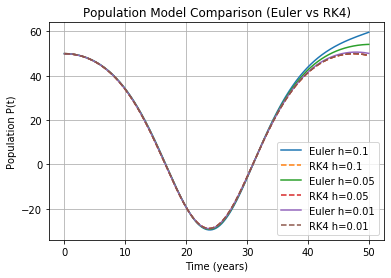

In [21]:
P0 = 50
V0 = 0
t0 = 0
tf = 50   # 50 years 

step_sizes = [0.1, 0.05, 0.01]


# Run Simulations
plt.figure()

for h in step_sizes:
    t_e, P_e = euler_method(P0, V0, t0, tf, h)
    t_rk, P_rk = rk4_method(P0, V0, t0, tf, h)

    plt.plot(t_e, P_e, label=f"Euler h={h}")
    plt.plot(t_rk, P_rk, linestyle='--', label=f"RK4 h={h}")


# Plot Formatting
plt.xlabel("Time (years)")
plt.ylabel("Population P(t)")
plt.title("Population Model Comparison (Euler vs RK4)")
plt.legend()
plt.grid()

plt.show()


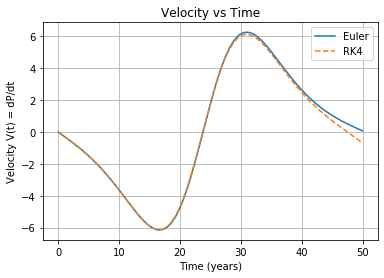

In [29]:
plt.figure()

h = 0.05  # choose a representative step size

t_e, P_e, V_e = euler_method(P0, V0, t0, tf, h)
t_rk, P_rk, V_rk = rk4_method(P0, V0, t0, tf, h)

plt.plot(t_e, V_e, label="Euler")
plt.plot(t_rk, V_rk, linestyle='--', label="RK4")

plt.xlabel("Time (years)")
plt.ylabel("Velocity V(t) = dP/dt")
plt.title("Velocity vs Time")
plt.legend()
plt.grid()

plt.show()

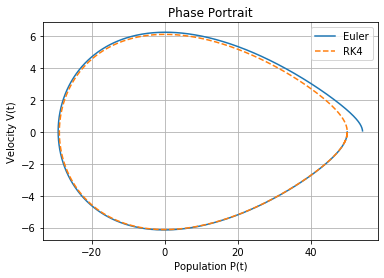

In [30]:
plt.figure()

plt.plot(P_e, V_e, label="Euler")
plt.plot(P_rk, V_rk, linestyle='--', label="RK4")

plt.xlabel("Population P(t)")
plt.ylabel("Velocity V(t)")
plt.title("Phase Portrait")
plt.legend()
plt.grid()

plt.show()

4) Stability Analysis 

- changing step size to larger intervals 
- error plot 
- physical iterpretation 

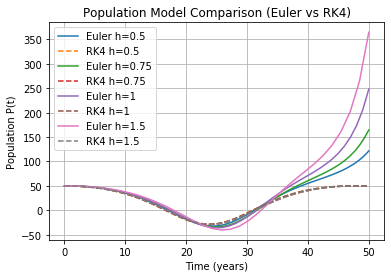

In [16]:
P0 = 50
V0 = 0
t0 = 0
tf = 50   # 50 years 

step_sizes = [0.5, 0.75, 1, 1.5]


# Run Simulations
plt.figure()

for h in step_sizes:
    t_e, P_e = euler_method(P0, V0, t0, tf, h)
    t_rk, P_rk = rk4_method(P0, V0, t0, tf, h)

    plt.plot(t_e, P_e, label=f"Euler h={h}")
    plt.plot(t_rk, P_rk, linestyle='--', label=f"RK4 h={h}")


# Plot Formatting
plt.xlabel("Time (years)")
plt.ylabel("Population P(t)")
plt.title("Population Model Comparison (Euler vs RK4)")
plt.legend()
plt.grid()

plt.show()

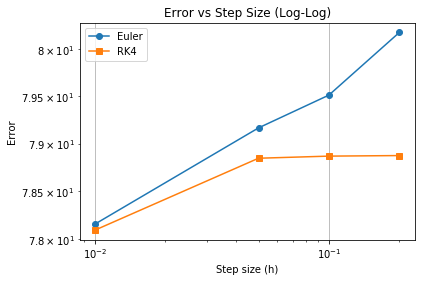

In [19]:
# Reference solution (very fine step)
t_ref, P_ref = rk4_method(P0, V0, t0, tf, 0.001)

def compute_error(P_coarse, P_ref):
    return np.max(np.abs(P_coarse - P_ref[:len(P_coarse)]))

hs = [0.2, 0.1, 0.05, 0.01]
euler_errors = []
rk4_errors = []

for h in hs:
    t_e, P_e = euler_method(P0, V0, t0, tf, h)
    t_rk, P_rk = rk4_method(P0, V0, t0, tf, h)

    euler_errors.append(compute_error(P_e, P_ref))
    rk4_errors.append(compute_error(P_rk, P_ref))
    
plt.figure()

plt.loglog(hs, euler_errors, 'o-', label="Euler")
plt.loglog(hs, rk4_errors, 's-', label="RK4")

plt.xlabel("Step size (h)")
plt.ylabel("Error")
plt.title("Error vs Step Size (Log-Log)")
plt.legend()
plt.grid()

plt.show()

For this ecological system, the population is expected to remain bounded and generally decline due to the negative growth rate. However, for large step sizes, numerical solutions (especially Euler’s method) exhibit non-physical behavior such as rapid oscillations and unbounded growth. These artifacts are purely numerical and do not reflect real population dynamics.

RK4 produces more stable and physically realistic results, even at moderately large step sizes. This demonstrates the importance of choosing an appropriate numerical method and step size when modeling nonlinear systems.